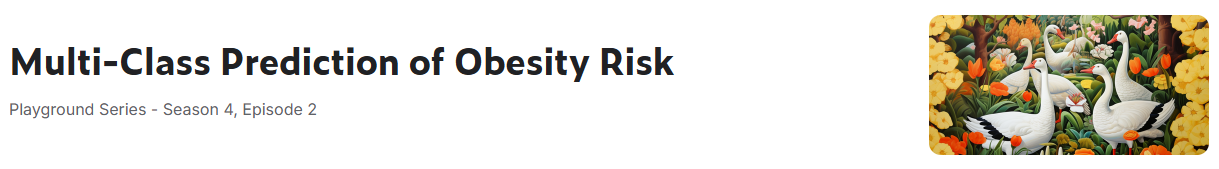

https://www.kaggle.com/competitions/playground-series-s4e2/overview

In [1]:
from sklearn import set_config
set_config(display="text")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

<pre>

① 데이터 불러오기
        ↓
② 데이터 기본 정보 확인
        ↓
③ 결측치 확인
        ↓
④ 중복값 확인
        ↓
⑤ Target 분포 확인
        ↓
⑥ 수치형 / 범주형 변수 구분
        ↓
⑦ EDA
   ├─ 수치형 변수 분석
   ├─ 범주형 변수 분석
   ├─ Target과의 관계
   └─ 이상치 확인
        ↓
⑧ 전처리
   ├─ 불필요한 컬럼 제거
   ├─ 범주형 변수 인코딩
   └─ 필요시 이상치/결측치 처리
        ↓
⑨ Train / Validation 분리
        ↓
⑩ 기본 모델 학습
   ├─ Logistic Regression
   ├─ Random Forest
   └─ LightGBM ⭐
        ↓
⑪ 모델 성능 비교
        ↓
⑫ Feature Engineering
        ↓
⑬ 교차검증 K-Fold
        ↓
⑭ LightGBM 하이퍼파라미터 튜닝
        ↓
⑮ 최종 모델 선정
        ↓
⑯ 전체 train으로 재학습
        ↓
⑰ test 예측
        ↓
⑱ submission.csv 생성
        ↓
⑲ Kaggle 제출
        ↓
⑳ 결과 확인 → 개선1

| 변수                               | 확인할 것                       |
| -------------------------------- | --------------------------- |
| `Gender`                         | 성별에 따라 비만 등급 분포가 달라지는가      |
| `family_history_with_overweight` | 가족력에 따라 등급 분포가 달라지는가        |
| `FAVC`                           | 고칼로리 음식 섭취 여부에 따라 차이가 있는가   |
| `CAEC`                           | 간식 섭취 빈도에 따라 차이가 있는가        |
| `SMOKE`                          | 흡연 여부에 따라 차이가 있는가           |
| `SCC`                            | 칼로리 섭취량 모니터링 여부에 따라 차이가 있는가 |
| `CALC`                           | 음주 빈도에 따라 차이가 있는가           |
| `MTRANS`                         | 이동수단에 따라 등급 분포가 달라지는가       |


| 값                     | 뜻       | 쉽게 말하면       |
| --------------------- | ------- | ------------ |
| `Insufficient_Weight` | 저체중     | 정상 체중보다 낮음   |
| `Normal_Weight`       | 정상 체중   | 정상 범위        |
| `Overweight_Level_I`  | 과체중 1단계 | 과체중          |
| `Overweight_Level_II` | 과체중 2단계 | 과체중이 더 높은 단계 |
| `Obesity_Type_I`      | 비만 1단계  | 비만           |
| `Obesity_Type_II`     | 비만 2단계  | 고도 비만 수준     |
| `Obesity_Type_III`    | 비만 3단계  | 가장 높은 비만 단계  |


# **[1] Data Load**
* target : heart disease

In [3]:
train = pd.read_csv("../../Datas/#obesity/train.csv") 
test = pd.read_csv("../../Datas/#obesity/test.csv")
sub = pd.read_csv("../../Datas/#obesity/sample_submission.csv")

<pre>
id                           : ID
Gender                       : 성별
Age                          : 나이
Height                       : 키(미터)
Weight                       : 몸무게(kg)
family_history_with_overweight : 가족 중 과체중/비만 여부
FAVC                         : 고칼로리 음식의 잦은 섭취 여부
FCVC                         : 채소 섭취 빈도
NCP                          : 하루 주요 식사 횟수
CAEC                         : 식사 사이 음식 섭취 빈도
SMOKE                        : 흡연 여부
CH2O                         : 하루 물 섭취량
SCC                          : 칼로리 섭취량 모니터링 여부
FAF                          : 신체 활동 빈도
TUE                          : 전자기기 사용 시간
CALC                         : 음주 빈도
MTRANS                       : 주요 이동 수단
NObeyesdad                   : 비만 수준

In [4]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  str    
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  str    
 6   FAVC                            20758 non-null  str    
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  str    
 10  SMOKE                           20758 non-null  str    
 11  CH2O                            20758 non-null  float64
 12  SCC                             20758 non-n

In [6]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 13840 entries, 0 to 13839
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              13840 non-null  int64  
 1   Gender                          13840 non-null  str    
 2   Age                             13840 non-null  float64
 3   Height                          13840 non-null  float64
 4   Weight                          13840 non-null  float64
 5   family_history_with_overweight  13840 non-null  str    
 6   FAVC                            13840 non-null  str    
 7   FCVC                            13840 non-null  float64
 8   NCP                             13840 non-null  float64
 9   CAEC                            13840 non-null  str    
 10  SMOKE                           13840 non-null  str    
 11  CH2O                            13840 non-null  float64
 12  SCC                             13840 non-n

In [7]:
train.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [8]:
train.columns

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

In [9]:
train.isnull().sum()
test.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64

* 결측 없음
* 글자 있음 > 인코딩 필요

In [10]:
#------중복값 확인
train.duplicated().sum()

np.int64(0)

# **[2] Target 분포 확인**
* target : 'NObeyesdad'

In [11]:
train['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

In [12]:
train['NObeyesdad'].value_counts(normalize=True)

NObeyesdad
Obesity_Type_III       0.194913
Obesity_Type_II        0.156470
Normal_Weight          0.148473
Obesity_Type_I         0.140187
Insufficient_Weight    0.121544
Overweight_Level_II    0.121495
Overweight_Level_I     0.116919
Name: proportion, dtype: float64

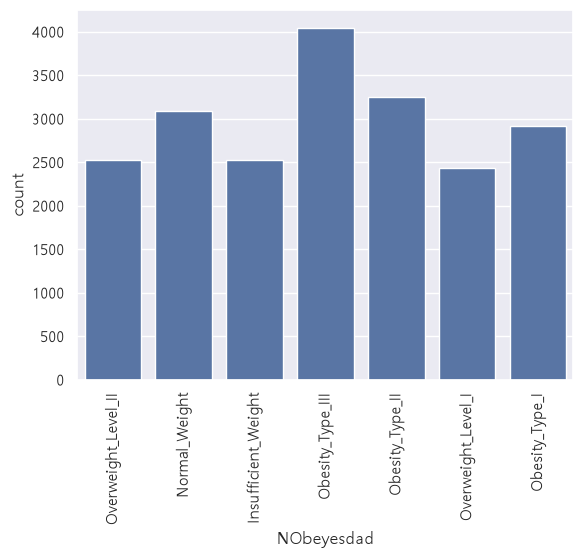

In [13]:
sns.countplot(x='NObeyesdad', data=train)
plt.xticks(rotation=90)
plt.show()

# **[3] EDA**

## 수치형

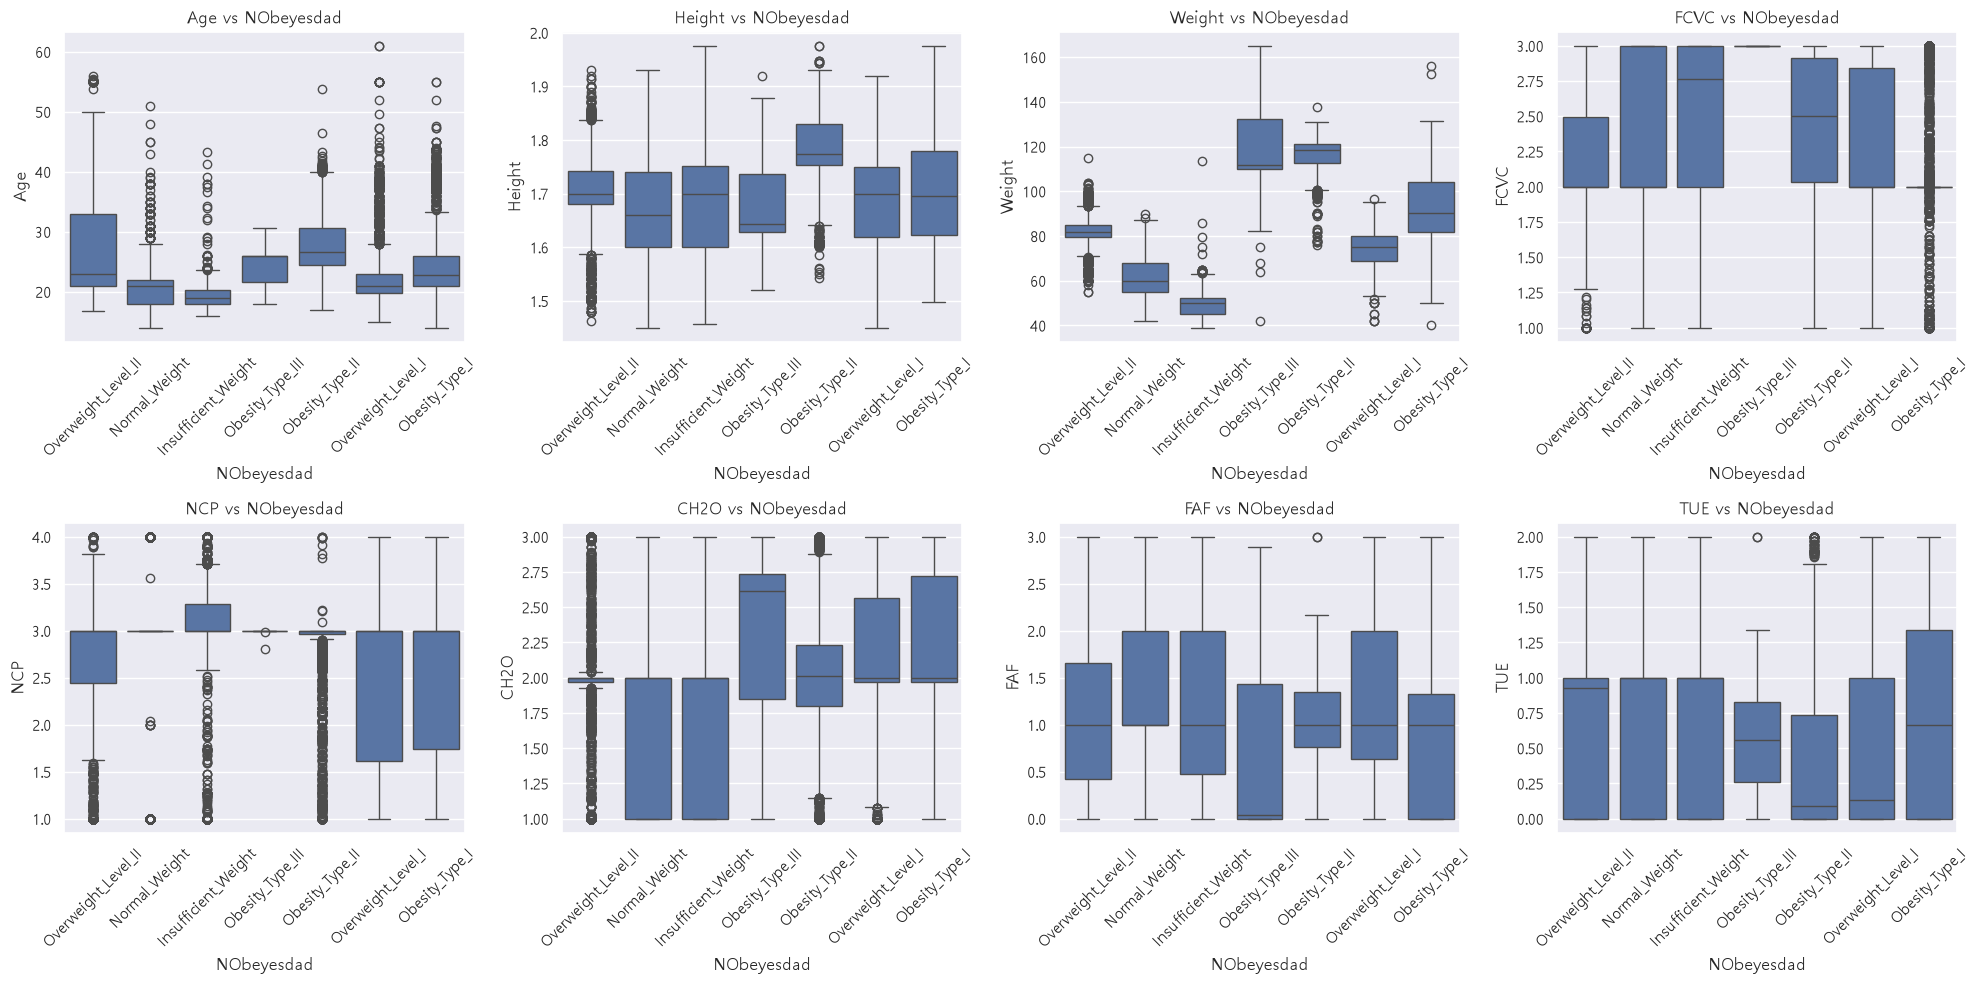

In [14]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(num_cols):
    row = i // 4
    col_num = i % 4
    
    sns.boxplot(
        x='NObeyesdad',
        y=col,
        data=train,
        ax=axes[row][col_num]
    )
    
    axes[row][col_num].set_title(f'{col} vs NObeyesdad')
    axes[row][col_num].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 분석
* Weight : 중앙값의 차이가 큼,  Insufficient_Weight → 약 50kg / Normal_Weight → 약 60kg / Overweight → 약 75~80kg / Obesity → 100kg 이상
  * BMI = Weight / Height**2 확인 필요
* Height : 영향력 있음

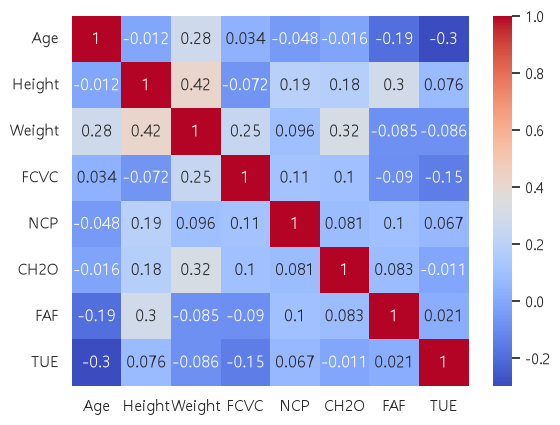

In [15]:
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

### 분석
* Age & TUE : -0.3
* Weight & Age : 0.28
* Weight & Height : 0.42
* Weight & FCVC : 0.25
* FAF & Height : 0.3
* CH20 & Weight : 0.32

## 파생피쳐 생성 : BMI

In [16]:
train['BMI'] = train['Weight'] / (train['Height'] ** 2)

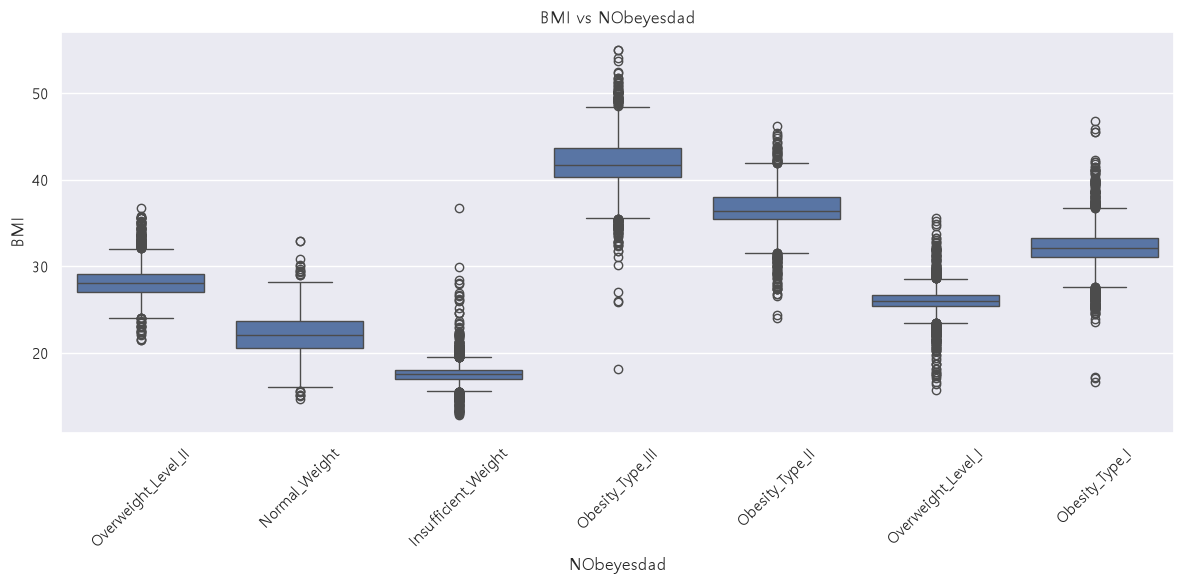

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='NObeyesdad',
    y='BMI',
    data=train
)

plt.xticks(rotation=45)
plt.title('BMI vs NObeyesdad')
plt.tight_layout()
plt.show()

In [18]:
test['BMI'] = test['Weight'] / (test['Height'] ** 2)

In [19]:
train[['Height', 'Weight', 'BMI']].head()

,Height,Weight,BMI
0,1.699998,81.669950,28.259565
1,1.560000,57.000000,23.422091
2,1.711460,50.165754,17.126706
3,1.710730,131.274851,44.855798
4,1.914186,93.798055,25.599151


## 범주형

In [20]:
cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS',
]

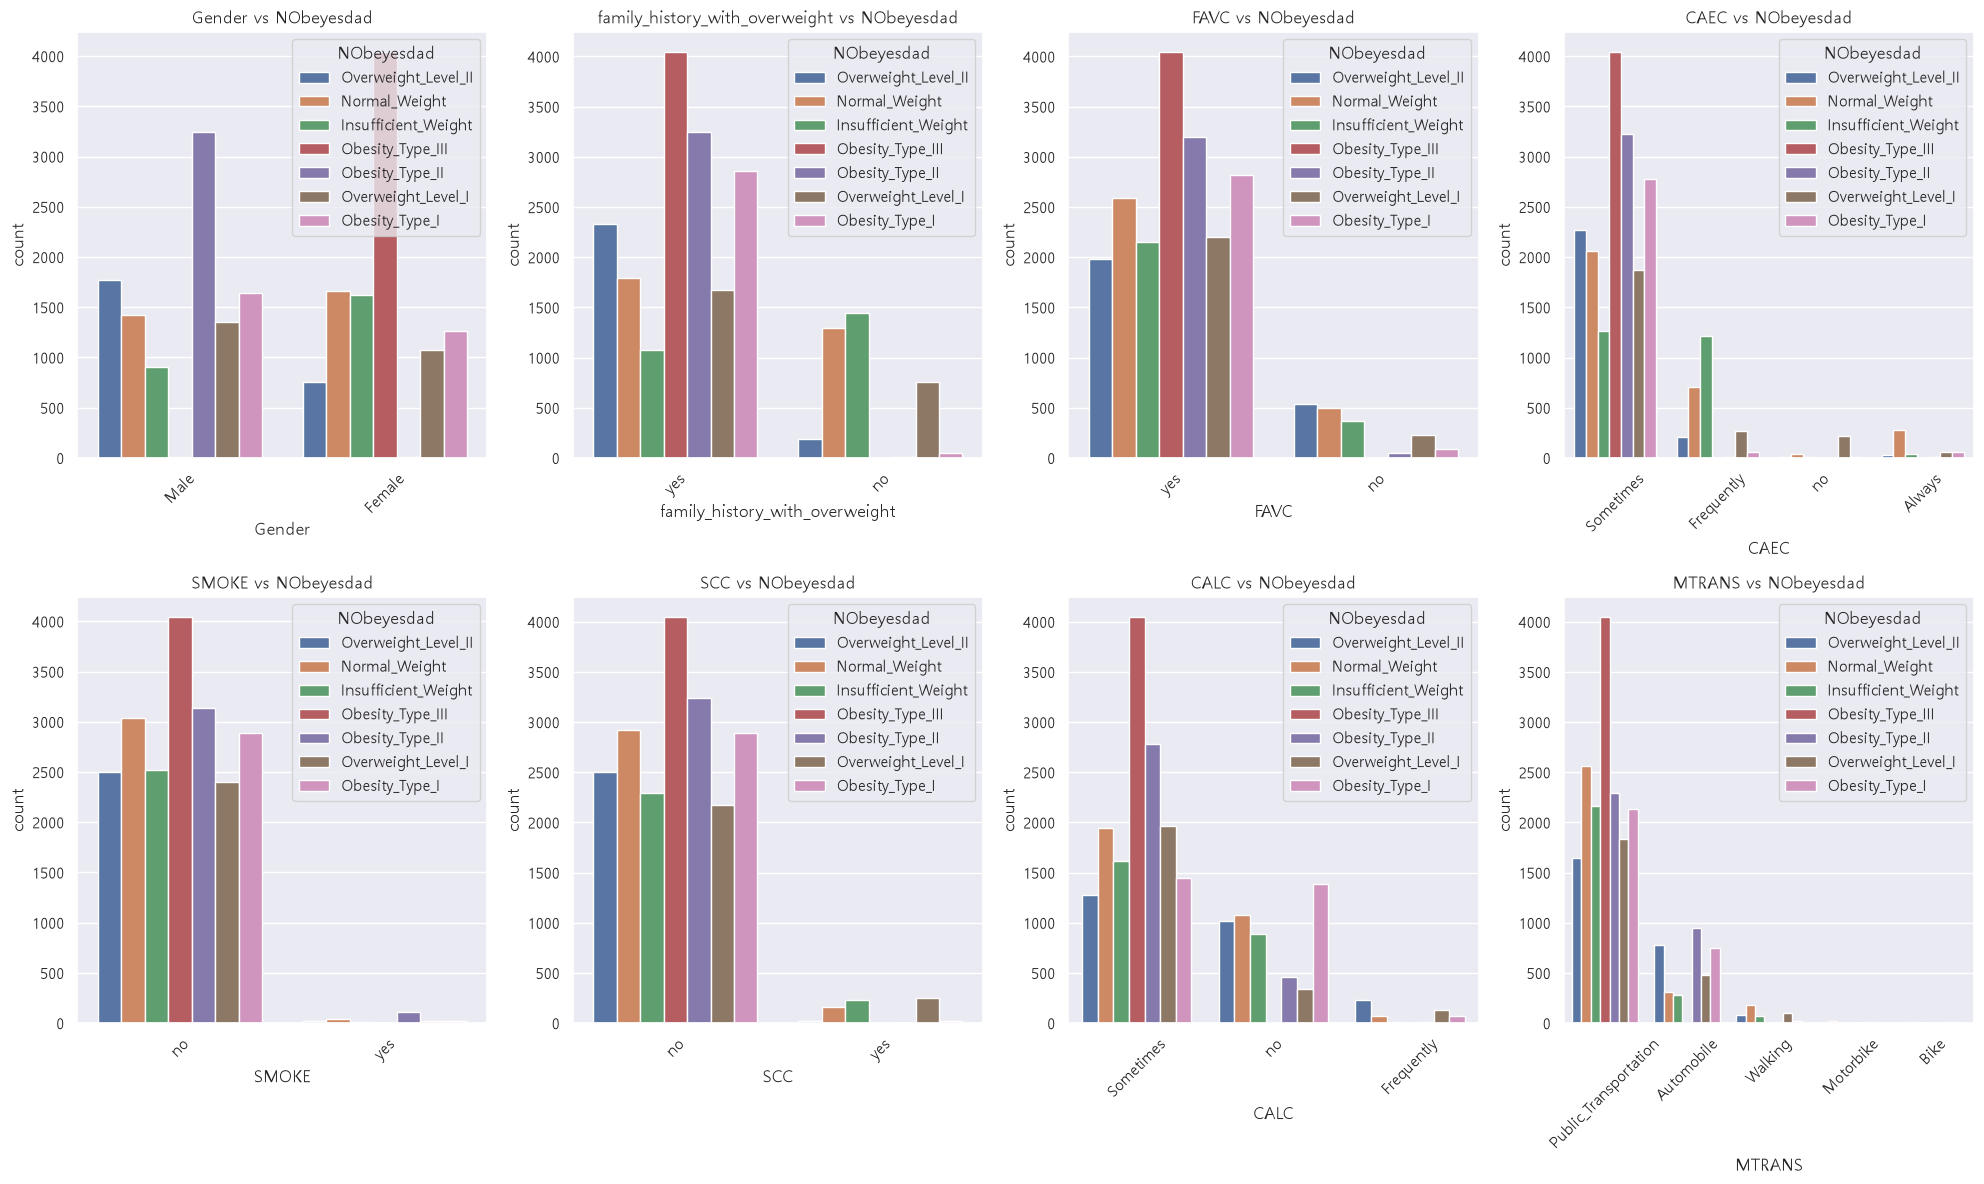

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=train,
        x=col,
        hue='NObeyesdad',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs NObeyesdad')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 분석
| 변수                               | 현재 그래프에서 판단     | 처리       |
| -------------------------------- | --------------- | -------- |
| `Gender`                         | 어느 정도 차이 있음     | 🟢 유지    |
| `family_history_with_overweight` | **차이가 매우 커 보임** | 🟢 중요    |
| `FAVC`                           | 그룹 크기 차이가 큼     | 🟡 비율 확인 |
| `CAEC`                           | 관계 가능성 있음       | 🟢 유지    |
| `SMOKE`                          | `no` 데이터가 압도적   | 🟡 비율 확인 |
| `SCC`                            | `no` 데이터가 압도적   | 🟡 비율 확인 |
| `CALC`                           | 관계 가능성 있음       | 🟡 비율 확인 |
| `MTRANS`                         | 그룹 크기 차이가 큼     | 🟡 비율 확인 |


| 값                     | 뜻       | 쉽게 말하면       |
| --------------------- | ------- | ------------ |
| `Insufficient_Weight` | 저체중     | 정상 체중보다 낮음   |
| `Normal_Weight`       | 정상 체중   | 정상 범위        |
| `Overweight_Level_I`  | 과체중 1단계 | 과체중          |
| `Overweight_Level_II` | 과체중 2단계 | 과체중이 더 높은 단계 |
| `Obesity_Type_I`      | 비만 1단계  | 비만           |
| `Obesity_Type_II`     | 비만 2단계  | 고도 비만 수준     |
| `Obesity_Type_III`    | 비만 3단계  | 가장 높은 비만 단계  |


### 범주별 비만 수준 비율

In [22]:
cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

for col in cat_cols:
    print(f'\n===== {col} =====')
    
    result = pd.crosstab(
        train[col],
        train['NObeyesdad'],
        normalize='index'
    ) * 100
    
    print(result.round(1))


===== Gender =====
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Gender                                                           
Female                     15.6           15.9            12.2   
Male                        8.7           13.8            15.9   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Gender                                                              
Female                  0.1              38.8                10.3   
Male                   31.3               0.0                13.1   

NObeyesdad  Overweight_Level_II  
Gender                           
Female                      7.2  
Male                       17.1  

===== family_history_with_overweight =====
NObeyesdad                      Insufficient_Weight  Normal_Weight  \
family_history_with_overweight                                       
no                                             38.7           34.5   
yes                                             

In [23]:
pd.crosstab(train['Gender'], train['NObeyesdad'])

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,1621,1660,1267,8,4041,1070,755
Male,902,1422,1643,3240,5,1357,1767


#### 분석

* Gender, family_history_with_overweight, FAVC, CAEC, SCC에서 NObeyesdad 클래스별 분포 차이가 크게 나타남
* 특히 가족력 유무에 따라 비만 등급의 분포가 크게 달라졌으며, 성별에 따라서도 Obesity_Type_II와 Obesity_Type_III의 분포가 뚜렷하게 차이남
* SMOKE, CALC, MTRANS 역시 범주별 분포 차이가 확인되었으나 일부 범주의 표본 수가 적어 모델링을 통한 추가 검증이 필요하다.
| 변수                                 | 주요 분포/특징                                                                | `NObeyesdad`와의 관계                               | 판단                |
| ---------------------------------- | ----------------------------------------------------------------------- | ----------------------------------------------- | ----------------- |
| **Gender**                         | 여성은 `Obesity_Type_III` 38.8%, 남성은 `Obesity_Type_II` 31.3%               | 성별에 따라 비만 등급 분포가 **매우 크게 다름**                   | 🟢 **중요**         |
| **family_history_with_overweight** | 가족력 `yes`에서 비만 등급 비율이 크게 증가                                             | 가족력 유무에 따른 차이가 **매우 큼**                         | 🟢 **매우 중요**      |
| **FAVC**                           | `yes`에서 비만 I·II·III 비율이 높음                                              | 고칼로리 음식 섭취 여부에 따라 **뚜렷한 차이**                    | 🟢 **중요**         |
| **CAEC**                           | `no`는 `Overweight_Level_I` 78.5%, `Sometimes`는 `Obesity_Type_III` 23.1% | 간식 섭취 빈도에 따라 **분포가 크게 달라짐**                     | 🟢 **중요**         |
| **SMOKE**                          | `no`가 대부분, `yes`는 표본이 적음                                                | `yes`에서 `Obesity_Type_II` 46.5%로 높지만 표본 수 확인 필요 | 🟡 **유지 후 모델 확인** |
| **SCC**                            | `no`가 대부분, `yes`는 저체중·과체중 비율이 높음                                        | `yes`에서 비만 II·III가 거의 없음                        | 🟢 **관계 있음**      |
| **CALC**                           | `Sometimes`가 많고, `Frequently`는 표본이 적음                                   | 음주 빈도에 따라 target 분포 차이가 있음                      | 🟡 **유지 후 모델 확인** |
| **MTRANS**                         | `Public_Transportation`이 대부분                                            | 이동수단에 따라 target 분포 차이가 존재                       | 🟡 **유지 후 모델 확인** |


# **[4] 전처리**

## 'id' 컬럼 삭제

In [24]:
train = train.drop(columns=['id'])

In [25]:
test = test.drop(columns=['id'])

In [26]:
train.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II,28.259565
1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight,23.422091
2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight,17.126706
3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III,44.855798
4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II,25.599151


## 인코딩

In [27]:
train['family_history_with_overweight'].value_counts()

family_history_with_overweight
yes    17014
no      3744
Name: count, dtype: int64

In [28]:
train['FAVC'].value_counts()

FAVC
yes    18982
no      1776
Name: count, dtype: int64

In [29]:
train['CAEC'].value_counts()

CAEC
Sometimes     17529
Frequently     2472
Always          478
no              279
Name: count, dtype: int64

In [30]:
train['SMOKE'].value_counts()

SMOKE
no     20513
yes      245
Name: count, dtype: int64

In [31]:
train['SCC'].value_counts()

SCC
no     20071
yes      687
Name: count, dtype: int64

In [32]:
train['CALC'].value_counts()

CALC
Sometimes     15066
no             5163
Frequently      529
Name: count, dtype: int64

### 원핫인코더

In [33]:
cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]


from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# train으로 인코더 학습 + 변환
train_encoded = encoder.fit_transform(train[cat_cols])

# test는 train에서 학습한 인코더로 변환
test_encoded = encoder.transform(test[cat_cols])

### 인코딩된 컬럼 이름

In [34]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=test.index
)

### 데이터 합치기

In [35]:
# 범주형 컬럼 제거
train_num = train.drop(columns=cat_cols)
test_num = test.drop(columns=cat_cols)

# 인코딩 결과 합치기
train_enc = pd.concat([train_num, train_encoded], axis=1)
test_enc = pd.concat([test_num, test_encoded], axis=1)

In [36]:
train_enc.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,BMI,...,SCC_no,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,24.443011,1.699998,81.669950,2.000000,2.983297,2.763573,0.000000,0.976473,Overweight_Level_II,28.259565,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,18.000000,1.560000,57.000000,2.000000,3.000000,2.000000,1.000000,1.000000,Normal_Weight,23.422091,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,18.000000,1.711460,50.165754,1.880534,1.411685,1.910378,0.866045,1.673584,Insufficient_Weight,17.126706,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,20.952737,1.710730,131.274851,3.000000,3.000000,1.674061,1.467863,0.780199,Obesity_Type_III,44.855798,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,31.641081,1.914186,93.798055,2.679664,1.971472,1.979848,1.967973,0.931721,Overweight_Level_II,25.599151,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [37]:
test_enc.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_Female,...,SCC_no,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,26.899886,1.848294,120.644178,2.938616,3.000000,2.825629,0.855400,0.000000,35.315411,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,21.000000,1.600000,66.000000,2.000000,1.000000,3.000000,1.000000,0.000000,25.781250,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,26.000000,1.643355,111.600553,3.000000,3.000000,2.621877,0.000000,0.250502,41.324115,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,20.979254,1.553127,103.669116,2.000000,2.977909,2.786417,0.094851,0.000000,42.976937,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,26.000000,1.627396,104.835346,3.000000,3.000000,2.653531,0.000000,0.741069,39.584143,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# **[5] Train / Validation 분리**
* 지금처럼 NObeyesdad가 7개 클래스인 다중분류에서는 stratify=y를 넣어주는 게 중요 == 비만 등급의 비율을 Train과 Validation에 비슷하게 유지

In [38]:
X = train_enc.drop(columns='NObeyesdad')
y = train_enc['NObeyesdad']

In [39]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)

print('\ny_train 분포')
print(y_train.value_counts(normalize=True).round(3))

print('\ny_val 분포')
print(y_val.value_counts(normalize=True).round(3))

X_train: (16606, 31)
X_val: (4152, 31)

y_train 분포
NObeyesdad
Obesity_Type_III       0.195
Obesity_Type_II        0.156
Normal_Weight          0.148
Obesity_Type_I         0.140
Insufficient_Weight    0.122
Overweight_Level_II    0.122
Overweight_Level_I     0.117
Name: proportion, dtype: float64

y_val 분포
NObeyesdad
Obesity_Type_III       0.195
Obesity_Type_II        0.157
Normal_Weight          0.149
Obesity_Type_I         0.140
Insufficient_Weight    0.122
Overweight_Level_II    0.121
Overweight_Level_I     0.117
Name: proportion, dtype: float64


# 현재상태
<pre>
EDA ✅
 ├─ 수치형 EDA
 ├─ BMI 추가
 ├─ 상관관계 확인
 ├─ 범주형 EDA
 └─ Target 분포 확인

전처리 ✅
 ├─ ID 제거
 └─ 범주형 One-Hot Encoding

Train / Validation Split ✅
 └─ Stratified Split 완료

In [48]:
# 검증용 BMI 제외 버전
X_no_bmi = X.drop(columns='BMI')

X_train_no_bmi, X_val_no_bmi, y_train_no_bmi, y_val_no_bmi = train_test_split(
    X_no_bmi,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **[6] 공통함수**

In [49]:
def myscore333(model, X_train, X_val, y_train, y_val):

    print(model.__class__.__name__)

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average='weighted')
    precision = precision_score(y_val, pred, average='weighted')
    recall = recall_score(y_val, pred, average='weighted')

    print(
        f"acc : {acc:.4f}  "
        f"f1 : {f1:.4f}  "
        f"precision : {precision:.4f}  "
        f"recall : {recall:.4f}"
    )

    cm = confusion_matrix(y_val, pred)
    print(cm)

    return model

# **[7] 모델 비교**

# <font color=darkorange> **※1차 점수※**
* Random Forest - acc : 0.9034
* <b> LGBMClassifier - acc : 0.9092
* LogisticRegression - acc : 0.8555

## Random Forest : acc

In [50]:
rf = RandomForestClassifier(n_estimators=100, random_state=1234)

myscore333(rf, X_train, X_val, y_train, y_val)

RandomForestClassifier
acc : 0.9034  f1 : 0.9031  precision : 0.9029  recall : 0.9034
[[479  25   0   0   0   1   0]
 [ 31 550   1   0   0  30   5]
 [  1   1 514  15   3  13  35]
 [  0   0  20 630   0   0   0]
 [  0   0   2   1 806   0   0]
 [  1  43  13   0   0 365  63]
 [  0   6  39   4   0  48 407]]


RandomForestClassifier(random_state=1234)

## LightGBM : acc

In [51]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=1234, verbose=-1)

myscore333(lgbm, X_train, X_val, y_train, y_val)

LGBMClassifier
acc : 0.9092  f1 : 0.9089  precision : 0.9088  recall : 0.9092
[[480  22   0   0   0   3   0]
 [ 27 555   3   0   0  26   6]
 [  1   1 517  17   3  11  32]
 [  0   0  18 632   0   0   0]
 [  0   0   3   1 805   0   0]
 [  1  39  13   0   0 374  58]
 [  0   7  39   3   0  43 412]]


LGBMClassifier(random_state=1234, verbose=-1)

## Logistic : acc

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
lr = LogisticRegression(max_iter=1000, random_state=1234)

myscore333(lr, X_train, X_val, y_train, y_val)

LogisticRegression
acc : 0.8555  f1 : 0.8539  precision : 0.8532  recall : 0.8555
[[476  28   0   0   0   1   0]
 [ 59 502   2   0   0  45   9]
 [  1   1 469  41  16  10  44]
 [  0   0  23 625   1   0   1]
 [  0   0   6   1 802   0   0]
 [  1  51  13   0   1 329  90]
 [  0   6  82   9   0  58 349]]


LogisticRegression(max_iter=1000, random_state=1234)

# **[8] Feature Engineering**

# <font color=darkorange> **※BMI 검증※**
* <b> LGBMClassifier - acc : 0.9082  ---> 파생피쳐 유지

In [54]:
lgbm_no_bmi = LGBMClassifier(
    random_state=1234,
    verbose=-1
)

myscore333(
    lgbm_no_bmi,
    X_train_no_bmi,
    X_val_no_bmi,
    y_train_no_bmi,
    y_val_no_bmi
)

LGBMClassifier
acc : 0.9082  f1 : 0.9080  precision : 0.9078  recall : 0.9082
[[476  27   0   0   0   2   0]
 [ 27 555   2   0   0  27   6]
 [  1   0 513  17   3  13  35]
 [  0   0  17 633   0   0   0]
 [  0   0   1   1 806   1   0]
 [  1  41  11   0   0 379  53]
 [  0   7  40   4   0  44 409]]


LGBMClassifier(random_state=1234, verbose=-1)

# **[9] 교차검증**

## K-Fold Cross Validation
* 평균 성능 : 0.9037

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

X = train_enc.drop(columns=['NObeyesdad'])
y = train_enc['NObeyesdad']

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for kf, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMClassifier(
        random_state=1234,
        verbose=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f'kf {kf} acc : {acc:.4f}')

print()
print(f'CV acc : {sum(scores) / len(scores):.4f}')

kf 1 acc : 0.9066
kf 2 acc : 0.9017
kf 3 acc : 0.9075
kf 4 acc : 0.8976
kf 5 acc : 0.9051

CV acc : 0.9037


# **[10] 모델튜닝**

<pre>

1단계

먼저 n_estimators + learning_rate

100 / 0.1
200 / 0.1
300 / 0.05
500 / 0.05

비교

↓

2단계

좋은 조합을 기준으로 num_leaves

15
31
50
70

비교

↓

3단계

max_depth, min_child_samples 조정

↓

4단계

최종 조합으로 CV 재확인

### 'n_estimators', 'learning_rate'
* 기본값 고정
* n_estimators=100, learning_rate=0.1

In [56]:
# 현재 데이터
X = train_enc.drop(columns=['NObeyesdad'])
y = train_enc['NObeyesdad']

# 5-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 비교할 파라미터 조합
params_list = [
    {'n_estimators': 100, 'learning_rate': 0.1},
    {'n_estimators': 200, 'learning_rate': 0.1},
    {'n_estimators': 300, 'learning_rate': 0.05},
    {'n_estimators': 500, 'learning_rate': 0.05}
]

results = []

for params in params_list:

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LGBMClassifier(
            random_state=1234,
            verbose=-1,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate']
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_val)

        acc = accuracy_score(y_val, pred)
        scores.append(acc)

    cv_score = sum(scores) / len(scores)

    results.append({
        'n_estimators': params['n_estimators'],
        'learning_rate': params['learning_rate'],
        'CV_Accuracy': cv_score
    })

    print(
        f"n_estimators={params['n_estimators']}, "
        f"learning_rate={params['learning_rate']} "
        f"→ CV Accuracy : {cv_score:.4f}"
    )

n_estimators=100, learning_rate=0.1 → CV Accuracy : 0.9037
n_estimators=200, learning_rate=0.1 → CV Accuracy : 0.9030
n_estimators=300, learning_rate=0.05 → CV Accuracy : 0.9034
n_estimators=500, learning_rate=0.05 → CV Accuracy : 0.9032


### 'num_leaves'
* 기본값 고정
* 'num_leaves'=31

In [57]:
params_list = [
    {'num_leaves': 15},
    {'num_leaves': 31},
    {'num_leaves': 50},
    {'num_leaves': 70}
]

results = []

for params in params_list:

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LGBMClassifier(
            random_state=1234,
            verbose=-1,
            n_estimators=100,
            learning_rate=0.1,
            num_leaves=params['num_leaves']
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_val)

        acc = accuracy_score(y_val, pred)
        scores.append(acc)

    cv_score = sum(scores) / len(scores)

    results.append({
        'num_leaves': params['num_leaves'],
        'CV_Accuracy': cv_score
    })

    print(
        f"num_leaves={params['num_leaves']} "
        f"→ CV Accuracy : {cv_score:.4f}"
    )

num_leaves=15 → CV Accuracy : 0.9037
num_leaves=31 → CV Accuracy : 0.9037
num_leaves=50 → CV Accuracy : 0.9032
num_leaves=70 → CV Accuracy : 0.9030


### 'max_depth'
* <b> 'max_depth'=5로 튜닝 : 0.9068

In [58]:
params_list = [
    {'max_depth': -1},
    {'max_depth': 5},
    {'max_depth': 7},
    {'max_depth': 10}
]

results = []

for params in params_list:

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LGBMClassifier(
            random_state=1234,
            verbose=-1,
            n_estimators=100,
            learning_rate=0.1,
            num_leaves=31,
            max_depth=params['max_depth']
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_val)

        acc = accuracy_score(y_val, pred)
        scores.append(acc)

    cv_score = sum(scores) / len(scores)

    results.append({
        'max_depth': params['max_depth'],
        'CV_Accuracy': cv_score
    })

    print(
        f"max_depth={params['max_depth']} "
        f"→ CV Accuracy : {cv_score:.4f}"
    )

max_depth=-1 → CV Accuracy : 0.9037
max_depth=5 → CV Accuracy : 0.9068
max_depth=7 → CV Accuracy : 0.9035
max_depth=10 → CV Accuracy : 0.9040


### 'max_depth'
* 기본값 고정
* 'min_child_samples': 20

In [59]:
params_list = [
    {'min_child_samples': 10},
    {'min_child_samples': 20},
    {'min_child_samples': 30},
    {'min_child_samples': 50}
]

results = []

for params in params_list:

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LGBMClassifier(
            random_state=1234,
            verbose=-1,
            n_estimators=100,
            learning_rate=0.1,
            num_leaves=31,
            max_depth=5,
            min_child_samples=params['min_child_samples']
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_val)

        acc = accuracy_score(y_val, pred)
        scores.append(acc)

    cv_score = sum(scores) / len(scores)

    results.append({
        'min_child_samples': params['min_child_samples'],
        'CV_Accuracy': cv_score
    })

    print(
        f"min_child_samples={params['min_child_samples']} "
        f"→ CV Accuracy : {cv_score:.4f}"
    )

min_child_samples=10 → CV Accuracy : 0.9061
min_child_samples=20 → CV Accuracy : 0.9068
min_child_samples=30 → CV Accuracy : 0.9053
min_child_samples=50 → CV Accuracy : 0.9051


## 최종 튜닝 결과
* n_estimators=100, learning_rate=0.1
* num_leaves=31
* <font color=blue> <b> max_depth=5  ---> 0.9068
* min_child_samples: 20

In [60]:
final_model = LGBMClassifier(
    random_state=1234,
    verbose=-1,
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=5,
    min_child_samples=20
)

scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    final_model.fit(X_train, y_train)

    pred = final_model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f"Fold Accuracy : {acc:.4f}")

cv_score = sum(scores) / len(scores)

print(f"\nFinal CV Accuracy : {cv_score:.4f}")

Fold Accuracy : 0.9097
Fold Accuracy : 0.9044
Fold Accuracy : 0.9133
Fold Accuracy : 0.9015
Fold Accuracy : 0.9051

Final CV Accuracy : 0.9068


# **[11] 최종학습**

## fit

In [62]:
final_model.fit(X, y)

LGBMClassifier(max_depth=5, random_state=1234, verbose=-1)

In [64]:
print(test_enc.columns)

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI',
       'Gender_Female', 'Gender_Male', 'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes',
       'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no',
       'SMOKE_no', 'SMOKE_yes', 'SCC_no', 'SCC_yes', 'CALC_Frequently',
       'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile', 'MTRANS_Bike',
       'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking'],
      dtype='str')


In [65]:
X_test = test_enc.copy()

In [66]:
print(X.shape)
print(X_test.shape)

print(X.columns.equals(X_test.columns))

(20758, 31)
(13840, 31)
True


## pred

In [67]:
test_pred = final_model.predict(X_test)

In [68]:
print(test_pred[:10])
print(len(test_pred))

['Obesity_Type_II' 'Overweight_Level_I' 'Obesity_Type_III'
 'Obesity_Type_I' 'Obesity_Type_III' 'Insufficient_Weight'
 'Insufficient_Weight' 'Normal_Weight' 'Overweight_Level_II'
 'Normal_Weight']
13840


In [69]:
test_pred = final_model.predict(X_test)

In [70]:
print(test_pred[:10])
print(len(test_pred))

['Obesity_Type_II' 'Overweight_Level_I' 'Obesity_Type_III'
 'Obesity_Type_I' 'Obesity_Type_III' 'Insufficient_Weight'
 'Insufficient_Weight' 'Normal_Weight' 'Overweight_Level_II'
 'Normal_Weight']
13840


In [71]:
print(pd.Series(test_pred).value_counts())

Obesity_Type_III       2624
Normal_Weight          2114
Obesity_Type_II        2107
Obesity_Type_I         2081
Overweight_Level_II    1763
Insufficient_Weight    1717
Overweight_Level_I     1434
Name: count, dtype: int64


## submission
sample_submission을 그대로 복사해서 예측값만 넣는 방식이 가장 안전

In [73]:
print(sub.head())
print(sub.columns)

      id     NObeyesdad
0  20758  Normal_Weight
1  20759  Normal_Weight
2  20760  Normal_Weight
3  20761  Normal_Weight
4  20762  Normal_Weight
Index(['id', 'NObeyesdad'], dtype='str')


In [75]:
submission = sub.copy()

submission['NObeyesdad'] = test_pred

submission.to_csv('lec14_sub2_v1.csv', index=False)

# <font color=darkorange> **※1차 제출 점수※**
* 1491등

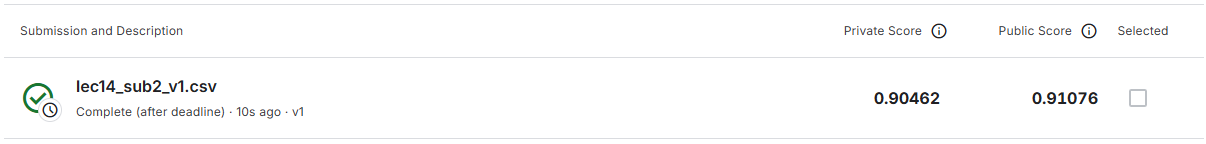

<pre>
LGBM
CV 0.9068
Private 0.90462
        ↓
① XGBoost baseline
        ↓
② XGBoost 튜닝
        ↓
③ LGBM + XGB 앙상블
        ↓
④ Feature Engineering 추가
        ↓
⑤ 필요하면 ordinal 방식 실험

# **[12] 모델교체&앙상블**

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_enc = le.fit_transform(y)

print(y_encoded[:10])
print(le.classes_)

[6 1 0 4 6 0 3 3 5 4]
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


## XGBoost 단독
* 탈락!

In [79]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

scores = []

for train_idx, val_idx in skf.split(X, y_encoded):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y_encoded[train_idx]
    y_val = y_encoded[val_idx]

    model = XGBClassifier(
        random_state=1234,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        eval_metric='mlogloss'
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f"Fold Accuracy : {acc:.4f}")

print(f"\nXGBoost CV Accuracy : {sum(scores) / len(scores):.4f}")

Fold Accuracy : 0.9104
Fold Accuracy : 0.9013
Fold Accuracy : 0.9070
Fold Accuracy : 0.8967
Fold Accuracy : 0.9015

XGBoost CV Accuracy : 0.9034


## LGBM + XGB 앙상블
* 이것도 탈락!

In [80]:
scores = []

for train_idx, val_idx in skf.split(X, y_encoded):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y_encoded[train_idx]
    y_val = y_encoded[val_idx]

    # LightGBM
    lgbm = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    # XGBoost
    xgb = XGBClassifier(
        random_state=1234,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        eval_metric='mlogloss'
    )

    lgbm.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    # 확률 예측
    lgbm_proba = lgbm.predict_proba(X_val)
    xgb_proba = xgb.predict_proba(X_val)

    # 50 : 50 앙상블
    ensemble_proba = (
        lgbm_proba * 0.5
        + xgb_proba * 0.5
    )

    pred = ensemble_proba.argmax(axis=1)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f"Fold Accuracy : {acc:.4f}")

print(f"\nEnsemble CV Accuracy : {sum(scores) / len(scores):.4f}")

Fold Accuracy : 0.9123
Fold Accuracy : 0.9025
Fold Accuracy : 0.9097
Fold Accuracy : 0.8988
Fold Accuracy : 0.9020

Ensemble CV Accuracy : 0.9050


# **[13] 전처리-2차**

## CAEC / CALC Ordinal Encoding
* One-Hot: 범주 사이의 순서 정보가 사라졌기 때문에
* no → Sometimes → Frequently → Always의 순서의 의미를 살릴 수 있게
* 이것도 탈락

In [82]:
# ==========================================
# Ordinal Encoding + One-Hot Encoding
# ==========================================

# 원본 데이터 복사
train_ord = train.copy()
test_ord = test.copy()


# ------------------------------------------
# 1. Ordinal Encoding
# ------------------------------------------

# CAEC : no < Sometimes < Frequently < Always
caec_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

# CALC : no < Sometimes < Frequently
calc_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2
}

train_ord['CAEC'] = train_ord['CAEC'].map(caec_map)
test_ord['CAEC'] = test_ord['CAEC'].map(caec_map)

train_ord['CALC'] = train_ord['CALC'].map(calc_map)
test_ord['CALC'] = test_ord['CALC'].map(calc_map)


# ------------------------------------------
# 2. One-Hot Encoding
# ------------------------------------------

cat_cols_ord = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'SMOKE',
    'SCC',
    'MTRANS'
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

train_encoded = encoder.fit_transform(
    train_ord[cat_cols_ord]
)

test_encoded = encoder.transform(
    test_ord[cat_cols_ord]
)

encoded_cols = encoder.get_feature_names_out(
    cat_cols_ord
)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=train_ord.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=test_ord.index
)


# ------------------------------------------
# 3. 수치형 + Ordinal + One-Hot 합치기
# ------------------------------------------

train_num = train_ord.drop(
    columns=cat_cols_ord
)

test_num = test_ord.drop(
    columns=cat_cols_ord
)

train_ord_enc = pd.concat(
    [train_num, train_encoded],
    axis=1
)

test_ord_enc = pd.concat(
    [test_num, test_encoded],
    axis=1
)


# ------------------------------------------
# 4. X / y 분리
# ------------------------------------------

X_ord = train_ord_enc.drop(
    columns=['NObeyesdad']
)

y_ord = train_ord_enc['NObeyesdad']


# ------------------------------------------
# 5. 컬럼 확인
# ------------------------------------------

print("Train shape :", train_ord_enc.shape)
print("Test shape  :", test_ord_enc.shape)

print("\nX shape :", X_ord.shape)
print("y shape :", y_ord.shape)

print("\nTrain/Test 컬럼 일치:",
      X_ord.columns.equals(test_ord_enc.columns))

print("\nOrdinal Encoding 확인")
print(train_ord[['CAEC', 'CALC']].head())

Train shape : (20758, 27)
Test shape  : (13840, 26)

X shape : (20758, 26)
y shape : (20758,)

Train/Test 컬럼 일치: True

Ordinal Encoding 확인
   CAEC  CALC
0     1     1
1     2     0
2     1     0
3     1     1
4     1     1


In [83]:
scores = []

for train_idx, val_idx in skf.split(X_ord, y_ord):

    X_train = X_ord.iloc[train_idx]
    X_val = X_ord.iloc[val_idx]

    y_train = y_ord.iloc[train_idx]
    y_val = y_ord.iloc[val_idx]

    model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f"Fold Accuracy : {acc:.4f}")

print(f"\nOrdinal Encoding CV Accuracy : {sum(scores) / len(scores):.4f}")

Fold Accuracy : 0.9085
Fold Accuracy : 0.9027
Fold Accuracy : 0.9104
Fold Accuracy : 0.9000
Fold Accuracy : 0.9058

Ordinal Encoding CV Accuracy : 0.9055


## 파생피쳐 생성 : WH_Ratio
* Weight / Height
* 이것도 탈락

In [84]:
# ==========================================
# Feature Engineering 2
# BMI + Weight/Height Ratio
# ==========================================

train_fe = train.copy()
test_fe = test.copy()


# ------------------------------------------
# 1. 새로운 Feature 추가
# ------------------------------------------

train_fe['Weight_Height_Ratio'] = (
    train_fe['Weight'] / train_fe['Height']
)

test_fe['Weight_Height_Ratio'] = (
    test_fe['Weight'] / test_fe['Height']
)


# ------------------------------------------
# 2. 범주형 변수
# ------------------------------------------

cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]


# ------------------------------------------
# 3. One-Hot Encoding
# ------------------------------------------

from sklearn.preprocessing import OneHotEncoder

encoder_fe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

train_encoded_fe = encoder_fe.fit_transform(
    train_fe[cat_cols]
)

test_encoded_fe = encoder_fe.transform(
    test_fe[cat_cols]
)

encoded_cols_fe = encoder_fe.get_feature_names_out(
    cat_cols
)

train_encoded_fe = pd.DataFrame(
    train_encoded_fe,
    columns=encoded_cols_fe,
    index=train_fe.index
)

test_encoded_fe = pd.DataFrame(
    test_encoded_fe,
    columns=encoded_cols_fe,
    index=test_fe.index
)


# ------------------------------------------
# 4. 수치형 + One-Hot 합치기
# ------------------------------------------

train_num_fe = train_fe.drop(
    columns=cat_cols
)

test_num_fe = test_fe.drop(
    columns=cat_cols
)

train_fe_enc = pd.concat(
    [train_num_fe, train_encoded_fe],
    axis=1
)

test_fe_enc = pd.concat(
    [test_num_fe, test_encoded_fe],
    axis=1
)


# ------------------------------------------
# 5. X / y
# ------------------------------------------

X_fe = train_fe_enc.drop(
    columns=['NObeyesdad']
)

y_fe = train_fe_enc['NObeyesdad']


# 확인
print("X_fe :", X_fe.shape)
print("test  :", test_fe_enc.shape)

print(
    "컬럼 일치 :",
    X_fe.columns.equals(test_fe_enc.columns)
)

X_fe : (20758, 32)
test  : (13840, 32)
컬럼 일치 : True


In [85]:
scores = []

for train_idx, val_idx in skf.split(X_fe, y_fe):

    X_train = X_fe.iloc[train_idx]
    X_val = X_fe.iloc[val_idx]

    y_train = y_fe.iloc[train_idx]
    y_val = y_fe.iloc[val_idx]

    model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    scores.append(acc)

    print(f"Fold Accuracy : {acc:.4f}")

print(
    f"\nBMI + Weight/Height Ratio "
    f"CV Accuracy : {sum(scores) / len(scores):.4f}"
)

Fold Accuracy : 0.9102
Fold Accuracy : 0.9027
Fold Accuracy : 0.9075
Fold Accuracy : 0.9003
Fold Accuracy : 0.9046

BMI + Weight/Height Ratio CV Accuracy : 0.9050


# **[14] Confusion Matrix**
* OOF(Out-of-Fold) 예측 : 5-Fold 전체에서 각 샘플의 예측을 모아서 보는 방식

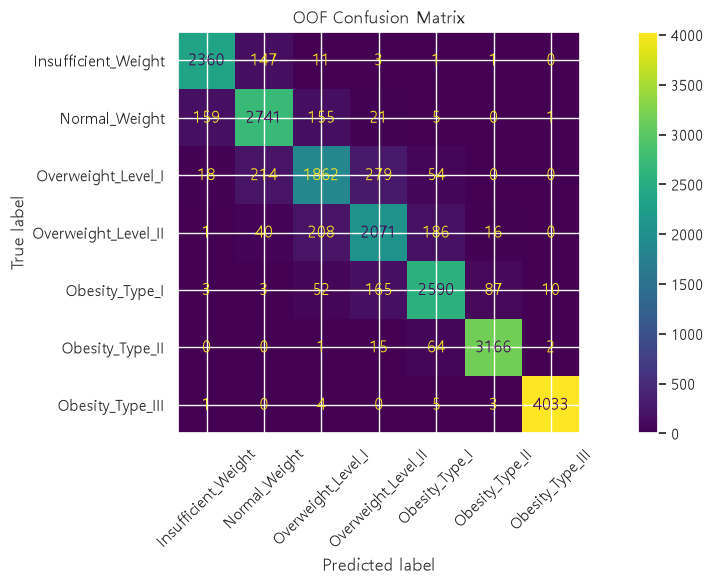

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# OOF 예측 저장
oof_pred = np.empty(len(y), dtype=object)

for train_idx, val_idx in skf.split(X, y):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    model.fit(X_train, y_train)

    oof_pred[val_idx] = model.predict(X_val)


# 클래스 순서 지정
class_names = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# Confusion Matrix
cm = confusion_matrix(
    y,
    oof_pred,
    labels=class_names
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 6))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title('OOF Confusion Matrix')
plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y,
        oof_pred,
        labels=class_names,
        target_names=class_names,
        digits=4
    )
)

                     precision    recall  f1-score   support

Insufficient_Weight     0.9284    0.9354    0.9319      2523
      Normal_Weight     0.8715    0.8894    0.8804      3082
 Overweight_Level_I     0.8120    0.7672    0.7890      2427
Overweight_Level_II     0.8109    0.8212    0.8160      2522
     Obesity_Type_I     0.8916    0.8900    0.8908      2910
    Obesity_Type_II     0.9673    0.9748    0.9710      3248
   Obesity_Type_III     0.9968    0.9968    0.9968      4046

           accuracy                         0.9068     20758
          macro avg     0.8969    0.8964    0.8965     20758
       weighted avg     0.9063    0.9068    0.9065     20758



## "Overweight I / II를 어떻게 더 잘 구분할까?"
| 클래스                     |     Recall | 해석         |
| ----------------------- | ---------: | ---------- |
| Insufficient_Weight     |     0.9354 | 👍 잘 맞춤    |
| Normal_Weight           |     0.8894 | 🟡 괜찮음     |
| **Overweight_Level_I**  | **0.7672** | 🔴 가장 어려움  |
| **Overweight_Level_II** | **0.8212** | 🔴 어려움     |
| Obesity_Type_I          |     0.8900 | 🟡         |
| Obesity_Type_II         |     0.9748 | 🟢 매우 잘 맞춤 |
| Obesity_Type_III        |     0.9968 | 🟢 거의 완벽   |


## 클래스별 BMI 분포

In [91]:
train.groupby('NObeyesdad')['BMI'].agg(
    ['count', 'min', 'mean', 'median', 'max']
).round(2)

,count,min,mean,median,max
NObeyesdad,,,,,
Insufficient_Weight,2523,12.87,17.58,17.51,36.78
Normal_Weight,3082,14.63,22.00,22.04,32.88
Obesity_Type_I,2910,16.60,32.15,32.12,46.81
Obesity_Type_II,3248,24.05,36.52,36.38,46.22
Obesity_Type_III,4046,18.18,41.78,41.75,55.00
Overweight_Level_I,2427,15.76,26.06,25.96,35.56
Overweight_Level_II,2522,21.51,28.19,28.02,36.74


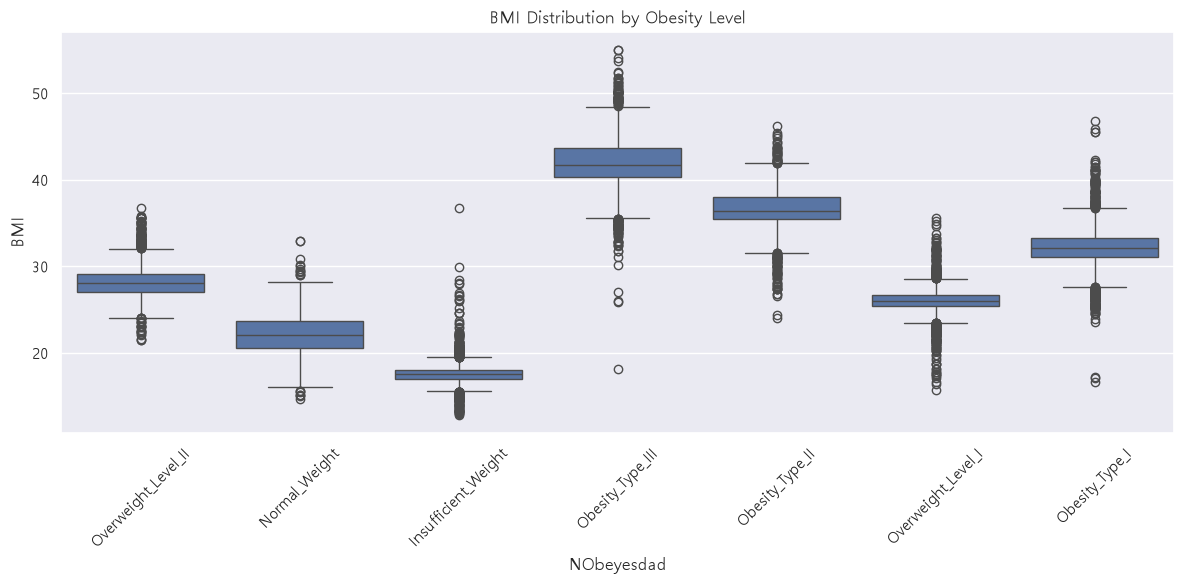

In [92]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='NObeyesdad',
    y='BMI',
    data=train
)

plt.xticks(rotation=45)
plt.title('BMI Distribution by Obesity Level')
plt.tight_layout()
plt.show()

### 분석
* Overweight I   → 중앙값 25.96
* Overweight II  → 중앙값 28.02
* 차이가 약 2.06 BMI밖에 안 됨 → 모델 입장에서는 구분 어려울 가능성

### 모델이 Overweight I / II를 틀린 데이터에서는 BMI가 어느 정도였는가?

In [93]:
error_df = pd.DataFrame({
    'true': y.values,
    'pred': oof_pred,
    'BMI': train['BMI'].values
})

# Overweight I ↔ Overweight II 오분류만 확인
error_ov = error_df[
    (
        (error_df['true'] == 'Overweight_Level_I') &
        (error_df['pred'] == 'Overweight_Level_II')
    )
    |
    (
        (error_df['true'] == 'Overweight_Level_II') &
        (error_df['pred'] == 'Overweight_Level_I')
    )
]

error_ov.groupby(['true', 'pred'])['BMI'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,,count,mean,median,min,max
true,pred,,,,,
Overweight_Level_I,Overweight_Level_II,279,27.57,27.67,24.11,33.30
Overweight_Level_II,Overweight_Level_I,208,26.36,26.23,22.45,32.15


In [94]:
check_df = error_df[
    error_df['true'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
]

check_df.groupby(['true', 'pred'])['BMI'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

count   mean  median    min    max
true                pred                                                   
Overweight_Level_I  Insufficient_Weight     18  18.52   17.99  15.76  26.89
                    Normal_Weight          214  23.69   24.19  17.45  28.76
                    Obesity_Type_I          54  30.78   31.29  23.84  35.56
                    Overweight_Level_I    1862  26.04   25.95  20.52  31.62
                    Overweight_Level_II    279  27.57   27.67  24.11  33.30
Overweight_Level_II Insufficient_Weight      1  24.56   24.56  24.56  24.56
                    Normal_Weight           40  24.37   24.30  21.51  31.20
                    Obesity_Type_I         186  31.22   31.49  25.13  35.62
                    Obesity_Type_II         16  32.79   33.96  27.42  35.85
                    Overweight_Level_I     208  26.36   26.23  22.45  32.15
                    Overweight_Level_II   2071  28.14   28.06  22.41  36.74

> 실제 Overweight I인데 II로 틀린 사람들은 BMI가 높은 편이고, <br>
> 실제 Overweight II인데 I로 틀린 사람들은 BMI가 낮은 편 <br>
 <b> 즉 모델이 단순히 랜덤하게 헷갈리는 게 아니라, BMI가 중간 영역에 있는 샘플을 중심으로 I ↔ II를 헷갈리고 있다 <br>
> <b> ✅ BMI는 중요한데, BMI 하나만으로는 I/II를 완전히 구분하지 못한다.

# **[15] 파생피쳐 검토**

## Gender × BMI
* 중앙값이 거의 다르지 않음, 의미 없음

In [95]:
train[
    train['NObeyesdad'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
].groupby(['Gender', 'NObeyesdad'])['BMI'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

count   mean  median    min    max
Gender NObeyesdad                                             
Female Overweight_Level_I    1070  26.13   26.00  15.76  35.56
       Overweight_Level_II    755  28.02   27.68  21.51  35.62
Male   Overweight_Level_I    1357  26.00   25.95  17.45  34.89
       Overweight_Level_II   1767  28.27   28.09  21.51  36.74

## Age × BMI
* 중앙값이 거의 다르지 않음, 의미 없음

In [96]:
train[
    train['NObeyesdad'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
].groupby('NObeyesdad')['Age'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
NObeyesdad,,,,,
Overweight_Level_I,2427,23.05,21.0,15.00,61.0
Overweight_Level_II,2522,26.03,23.0,16.83,56.0


In [97]:
train[
    train['NObeyesdad'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
].groupby('NObeyesdad')[['Age', 'BMI']].mean().round(2)

,Age,BMI
NObeyesdad,,
Overweight_Level_I,23.05,26.06
Overweight_Level_II,26.03,28.19


### Overweight_Level_I, II만 골라서 산점도

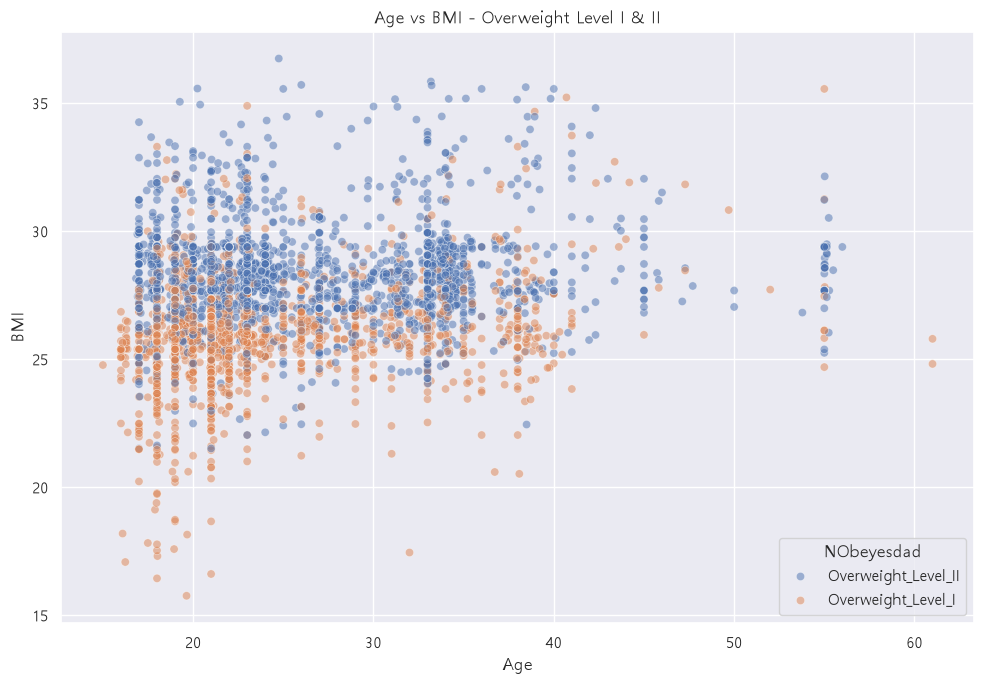

In [98]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train[
        train['NObeyesdad'].isin([
            'Overweight_Level_I',
            'Overweight_Level_II'
        ])
    ],
    x='Age',
    y='BMI',
    hue='NObeyesdad',
    alpha=0.5
)

plt.title('Age vs BMI - Overweight Level I & II')
plt.tight_layout()
plt.show()

# **[16] 경계 샘플만 다시 판단 : proba**

## 1단계 — OOF 확률 저장

In [99]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

oof_proba = np.zeros((len(X), 7))

for train_idx, val_idx in skf.split(X, y):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]

    model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    model.fit(X_train, y_train)

    oof_proba[val_idx] = model.predict_proba(X_val)

In [100]:
model.classes_

array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II'], dtype=object)

## 2단계 — I / II 확률만 뽑아보기
* 여기서 0.44 vs 0.46 처럼 비슷하면 모델이 "I인지 II인지 모르겠다"는 뜻

In [101]:
class_names = model.classes_

proba_df = pd.DataFrame(
    oof_proba,
    columns=class_names,
    index=train.index
)

proba_df[['Overweight_Level_I', 'Overweight_Level_II']].head(10)

,Overweight_Level_I,Overweight_Level_II
0,3.887098e-02,9.367567e-01
1,4.821914e-03,6.855045e-04
2,2.835498e-02,2.401139e-04
3,2.148072e-07,8.781980e-07
4,3.290938e-02,9.452179e-01
5,3.622156e-04,1.090046e-05
6,4.145808e-05,7.040821e-05
7,3.756664e-05,5.870252e-05
8,3.403005e-01,2.107685e-02
9,1.804234e-06,1.351813e-06


## 3단계 — 실제 I/II인 데이터만
* margin 수치가 작을수록 애매한 샘플

In [102]:
proba_check = pd.DataFrame({
    'true': y.values,
    'pred': oof_pred,
    'I_proba': proba_df['Overweight_Level_I'].values,
    'II_proba': proba_df['Overweight_Level_II'].values
})

proba_check = proba_check[
    proba_check['true'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
].copy()

proba_check.head(10)

,true,pred,I_proba,II_proba
0,Overweight_Level_II,Overweight_Level_II,0.038871,0.936757
4,Overweight_Level_II,Overweight_Level_II,0.032909,0.945218
8,Overweight_Level_I,Normal_Weight,0.340300,0.021077
10,Overweight_Level_I,Normal_Weight,0.283992,0.024550
16,Overweight_Level_II,Overweight_Level_II,0.029021,0.955250
18,Overweight_Level_II,Overweight_Level_II,0.024993,0.920705
20,Overweight_Level_II,Overweight_Level_II,0.072654,0.777760
29,Overweight_Level_II,Obesity_Type_I,0.005522,0.458640
33,Overweight_Level_II,Overweight_Level_II,0.192760,0.779640
35,Overweight_Level_I,Overweight_Level_I,0.846968,0.137576


In [103]:
proba_check['margin'] = abs(
    proba_check['I_proba'] -
    proba_check['II_proba']
)

proba_check.sort_values('margin').head(20)

,true,pred,I_proba,II_proba,margin
9979,Overweight_Level_I,Insufficient_Weight,0.000179,0.000017,0.000162
16890,Overweight_Level_II,Normal_Weight,0.024997,0.025279,0.000282
18697,Overweight_Level_I,Insufficient_Weight,0.000407,0.000015,0.000392
3323,Overweight_Level_I,Insufficient_Weight,0.000442,0.000043,0.000399
2384,Overweight_Level_I,Overweight_Level_I,0.485152,0.484453,0.000698
9008,Overweight_Level_II,Obesity_Type_II,0.000111,0.000835,0.000724
15542,Overweight_Level_II,Obesity_Type_I,0.021956,0.021152,0.000804
6093,Overweight_Level_I,Insufficient_Weight,0.001090,0.000102,0.000988
453,Overweight_Level_II,Obesity_Type_II,0.000180,0.001221,0.001041
14283,Overweight_Level_I,Insufficient_Weight,0.001134,0.000056,0.001078


<pre>
I_proba  = 0.000179
II_proba = 0.000017
margin   = 0.000162

* margin은 엄청 작지만, 이건 "I와 II 중 뭐가 맞는지 애매하다" 가 아니라
* "애초에 I와 II일 확률 자체가 거의 없다" 라는 뜻

> 실제로 pred가 Insufficient_Weight : 그래서 지금 나온 margin < 0.05 : 206개 를 보고 206개가 I/II 경계 샘플이다라고 판단하면 안 됨

## 4단계 — 애매한 샘플이 얼마나 많은지 확인

In [104]:
for threshold in [0.05, 0.10, 0.15, 0.20, 0.30]:

    count = (proba_check['margin'] < threshold).sum()

    print(
        f'margin < {threshold:.2f} : '
        f'{count}개 ({count / len(proba_check) * 100:.2f}%)'
    )

margin < 0.05 : 206개 (4.16%)
margin < 0.10 : 346개 (6.99%)
margin < 0.15 : 472개 (9.54%)
margin < 0.20 : 587개 (11.86%)
margin < 0.30 : 817개 (16.51%)


## 모델이 I 또는 II라고 판단한 샘플 중에서, I와 II의 확률이 비슷한 샘플

In [105]:
proba_ov = proba_check[
    proba_check['pred'].isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])
].copy()

print(f'전체 I/II 예측 샘플: {len(proba_ov)}개')

proba_ov.sort_values('margin').head(20)

전체 I/II 예측 샘플: 4420개


,true,pred,I_proba,II_proba,margin
2384,Overweight_Level_I,Overweight_Level_I,0.485152,0.484453,0.000698
16665,Overweight_Level_II,Overweight_Level_I,0.486031,0.483630,0.002401
19532,Overweight_Level_II,Overweight_Level_II,0.396189,0.400002,0.003813
3623,Overweight_Level_II,Overweight_Level_I,0.484050,0.479130,0.004921
14659,Overweight_Level_II,Overweight_Level_II,0.456057,0.461826,0.005769
20119,Overweight_Level_II,Overweight_Level_II,0.430693,0.436704,0.006012
1200,Overweight_Level_I,Overweight_Level_II,0.464341,0.471701,0.007360
12631,Overweight_Level_I,Overweight_Level_I,0.484350,0.476368,0.007982
14079,Overweight_Level_I,Overweight_Level_I,0.489179,0.480146,0.009033
15444,Overweight_Level_II,Overweight_Level_I,0.462723,0.451150,0.011574


In [106]:
for threshold in [0.05, 0.10, 0.15, 0.20, 0.30]:

    count = (proba_ov['margin'] < threshold).sum()

    print(
        f'margin < {threshold:.2f} : '
        f'{count}개 ({count / len(proba_ov) * 100:.2f}%)'
    )

margin < 0.05 : 71개 (1.61%)
margin < 0.10 : 132개 (2.99%)
margin < 0.15 : 201개 (4.55%)
margin < 0.20 : 263개 (5.95%)
margin < 0.30 : 405개 (9.16%)


# **[17] I vs II 전용 Binary Model**
* 각 Fold의 학습 데이터 안에서만 I/II Binary Model을 학습해야 함

<pre>
7개 클래스 LGBM
       ↓
  I 또는 II라고 판단
       ↓
I/II 전용 LGBM
       ↓
    I vs II

## 1단계 — I/II 전용 모델 성능부터 확인
* 개선 가능성 있음!
* Confusion Matrix와 비교하면
<pre>
기존 7-class에서 I/II 구분
약 79.5%
        ↓
I/II 전용 Binary 모델
88.4%

In [107]:
binary_scores = []

for train_idx, val_idx in skf.split(X, y):

    # 학습 데이터
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # 검증 데이터
    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    # 학습 데이터에서 I / II만 추출
    train_mask = y_train.isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])

    val_mask = y_val.isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])

    X_train_binary = X_train[train_mask]
    y_train_binary = y_train[train_mask]

    X_val_binary = X_val[val_mask]
    y_val_binary = y_val[val_mask]

    # I vs II 전용 모델
    binary_model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    binary_model.fit(
        X_train_binary,
        y_train_binary
    )

    binary_pred = binary_model.predict(X_val_binary)

    score = accuracy_score(
        y_val_binary,
        binary_pred
    )

    binary_scores.append(score)

    print(f'Fold {len(binary_scores)}: {score:.4f}')

print(f'\nBinary CV Mean: {np.mean(binary_scores):.4f}')

Fold 1: 0.8808
Fold 2: 0.8749
Fold 3: 0.8970
Fold 4: 0.8777
Fold 5: 0.8908

Binary CV Mean: 0.8842


## 2단계 — 모델 적용

In [108]:
# 기존 7-class 모델의 OOF 예측을 복사
corrected_oof_pred = oof_pred.copy()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # --------------------------------
    # 1. 기존 7-class 모델
    # --------------------------------
    base_model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    base_model.fit(X_train, y_train)

    base_pred = base_model.predict(X_val)

    # --------------------------------
    # 2. I / II 전용 Binary 데이터
    # --------------------------------
    binary_mask = y_train.isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])

    X_train_binary = X_train[binary_mask]
    y_train_binary = y_train[binary_mask]

    binary_model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    binary_model.fit(
        X_train_binary,
        y_train_binary
    )

    # --------------------------------
    # 3. 기존 모델이 I / II라고 예측한 샘플
    # --------------------------------
    ov_mask = np.isin(
        base_pred,
        ['Overweight_Level_I', 'Overweight_Level_II']
    )

    X_ov = X_val[ov_mask]

    # --------------------------------
    # 4. Binary 모델로 재예측
    # --------------------------------
    binary_pred = binary_model.predict(X_ov)

    # --------------------------------
    # 5. 기존 예측을 Binary 예측으로 교체
    # --------------------------------
    fold_pred = base_pred.copy()
    fold_pred[ov_mask] = binary_pred

    # OOF 위치에 저장
    corrected_oof_pred[val_idx] = fold_pred

    print(
        f'Fold {fold}: '
        f'{accuracy_score(y_val, fold_pred):.4f}'
    )

# 최종 CV Accuracy
corrected_score = accuracy_score(
    y,
    corrected_oof_pred
)

print(f'\n기존 LGBM CV: 0.9068')
print(f'Hierarchical CV: {corrected_score:.4f}')
print(f'개선폭: {corrected_score - 0.9068:+.4f}')

Fold 1: 0.9106
Fold 2: 0.9022
Fold 3: 0.9128
Fold 4: 0.9015
Fold 5: 0.9053

기존 LGBM CV: 0.9068
Hierarchical CV: 0.9065
개선폭: -0.0003


> 하........................

In [109]:
# threshold별 결과 저장
threshold_scores = {}

threshold_list = [
    0.50, 0.55, 0.60, 0.65, 0.70,
    0.75, 0.80, 0.85, 0.90
]

# threshold별로 사용할 OOF 예측 저장
threshold_oof = {
    threshold: oof_pred.copy()
    for threshold in threshold_list
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # ========================================
    # 1. 기존 7-class LGBM
    # ========================================
    base_model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    base_model.fit(X_train, y_train)

    base_pred = base_model.predict(X_val)

    # ========================================
    # 2. I / II 전용 Binary Model
    # ========================================
    binary_mask = y_train.isin([
        'Overweight_Level_I',
        'Overweight_Level_II'
    ])

    X_train_binary = X_train[binary_mask]
    y_train_binary = y_train[binary_mask]

    binary_model = LGBMClassifier(
        random_state=1234,
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=5,
        min_child_samples=20
    )

    binary_model.fit(
        X_train_binary,
        y_train_binary
    )

    # ========================================
    # 3. 기존 모델이 I / II라고 예측한 샘플
    # ========================================
    ov_mask = np.isin(
        base_pred,
        [
            'Overweight_Level_I',
            'Overweight_Level_II'
        ]
    )

    X_ov = X_val[ov_mask]

    # ========================================
    # 4. Binary 확률
    # ========================================
    binary_proba = binary_model.predict_proba(X_ov)

    binary_classes = binary_model.classes_

    I_idx = np.where(
        binary_classes == 'Overweight_Level_I'
    )[0][0]

    II_idx = np.where(
        binary_classes == 'Overweight_Level_II'
    )[0][0]

    I_proba = binary_proba[:, I_idx]
    II_proba = binary_proba[:, II_idx]

    binary_pred = binary_model.predict(X_ov)

    # Binary 모델의 예측 확률
    binary_confidence = np.maximum(
        I_proba,
        II_proba
    )

    # ========================================
    # 5. threshold별 예측 생성
    # ========================================
    for threshold in threshold_list:

        fold_pred = base_pred.copy()

        # Binary 모델이 threshold 이상 확신하는 샘플만 교체
        replace_mask = binary_confidence >= threshold

        # 실제 val 데이터에서의 위치
        ov_indices = np.where(ov_mask)[0]

        replace_indices = ov_indices[replace_mask]

        fold_pred[replace_indices] = binary_pred[replace_mask]

        # OOF 저장
        threshold_oof[threshold][val_idx] = fold_pred


# ========================================
# 6. threshold별 최종 Accuracy
# ========================================
print('기존 LGBM CV: 0.9068')
print()

for threshold in threshold_list:

    score = accuracy_score(
        y,
        threshold_oof[threshold]
    )

    threshold_scores[threshold] = score

    print(
        f'Threshold {threshold:.2f} → '
        f'{score:.4f} '
        f'({score - 0.9068:+.4f})'
    )

기존 LGBM CV: 0.9068

Threshold 0.50 → 0.9065 (-0.0003)
Threshold 0.55 → 0.9069 (+0.0001)
Threshold 0.60 → 0.9068 (-0.0000)
Threshold 0.65 → 0.9068 (+0.0000)
Threshold 0.70 → 0.9068 (-0.0000)
Threshold 0.75 → 0.9067 (-0.0001)
Threshold 0.80 → 0.9067 (-0.0001)
Threshold 0.85 → 0.9068 (-0.0000)
Threshold 0.90 → 0.9068 (-0.0000)


# **[18] Feature Importance**

In [112]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(20))

                              feature  importance
8                                 BMI        2982
2                              Weight        2591
0                                 Age        2369
1                              Height        1560
5                                CH2O        1061
3                                FCVC        1029
6                                 FAF         990
7                                 TUE         925
4                                 NCP         874
9                       Gender_Female         400
11  family_history_with_overweight_no         236
25                            CALC_no         222
16                    CAEC_Frequently         208
24                     CALC_Sometimes         147
13                            FAVC_no         144
29       MTRANS_Public_Transportation         144
17                     CAEC_Sometimes         114
15                        CAEC_Always         105
10                        Gender_Male         101


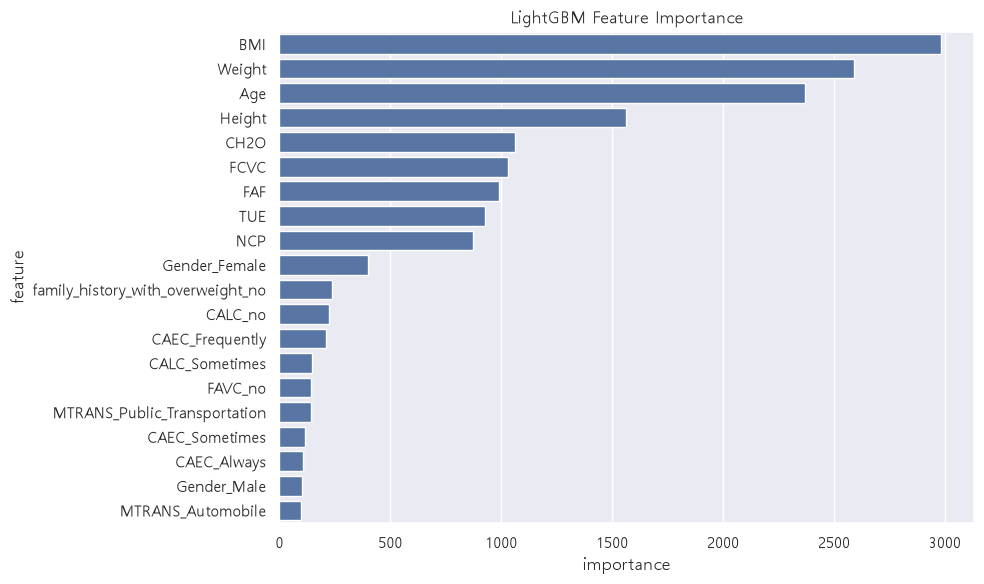

In [114]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature'
)

plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()